# Elevate MedSpa - Customer Segmentation (refined)

Segments 5,000 med-spa clients into behavioural cohorts with K-Means: includes the categorical channel/price variables, justifies k with elbow + silhouette, and profiles every cluster.

> All data is simulated for demonstration. No real customer data is used.

## 1. Load the data

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

CSV = 'medspa_customer_cohorts.csv'
if not os.path.exists(CSV):
    CSV = '/content/medspa_customer_cohorts.csv'
df = pd.read_csv(CSV)
print(df.shape)
df.head()

(5000, 12)


,Client_ID,Age,Gender,Location,Income,User_Interest,Acquisition_Source,Device_Type,Engagement_Time_Minutes,Price_Sensitivity,Purchase_Frequency,Average_Order_Value
0,EA-01502,37,Female,Suburban,56500,Skincare,Referral,Desktop,3.1,High,1,753.12
1,EA-02587,22,Female,Suburban,86000,Skincare,Facebook Ad,Mobile,1.2,Low,1,474.01
2,EA-02654,60,Female,Suburban,94000,Wellness,Organic Search,Tablet,11.3,Low,4,2500.00
3,EA-01056,43,Male,Urban,91500,Anti-aging,Organic Search,Mobile,13.5,Low,5,2256.96
4,EA-00706,32,Female,Urban,71500,Skincare,Groupon,Mobile,1.2,Medium,1,243.27


## 2. Data validation

In [2]:
print('Nulls:', df.isnull().sum().sum())
print('Duplicate Client_IDs:', df['Client_ID'].duplicated().sum())
df.describe(include='all').T

Nulls: 0
Duplicate Client_IDs: 0


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Client_ID,5000,5000,EA-01502,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,5000.0,NaN,NaN,NaN,34.8048,9.793645,19.0,28.0,33.0,41.0,72.0
Gender,5000,3,Female,4218,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Location,5000,3,Urban,2232,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Income,5000.0,NaN,NaN,NaN,69612.7,28094.688306,22000.0,49500.0,63500.0,85500.0,189500.0
User_Interest,5000,4,Bargains,2342,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Acquisition_Source,5000,4,Facebook Ad,2068,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Device_Type,5000,3,Mobile,3467,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Engagement_Time_Minutes,5000.0,NaN,NaN,NaN,6.61884,5.769016,0.4,2.7,4.5,8.9,38.3
Price_Sensitivity,5000,3,High,2603,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Build the feature matrix (the key fix)

The 5 numeric columns correlate 0.5-0.78, so alone they capture one 'spend' gradient. Adding the channel and price-sensitivity columns lets the clusters reflect the business question.

In [3]:
numeric_cols = ['Age','Income','Engagement_Time_Minutes','Purchase_Frequency','Average_Order_Value']
categorical_cols = ['Acquisition_Source','Price_Sensitivity']
dummies = pd.get_dummies(df[categorical_cols])
scaler = StandardScaler()
scaled_numeric = pd.DataFrame(scaler.fit_transform(df[numeric_cols]), columns=numeric_cols, index=df.index)
X = pd.concat([scaled_numeric, dummies.astype(float)], axis=1)
print('Feature matrix shape:', X.shape)
X.head()

Feature matrix shape: (5000, 12)


,Age,Income,Engagement_Time_Minutes,Purchase_Frequency,Average_Order_Value,Acquisition_Source_Facebook Ad,Acquisition_Source_Groupon,Acquisition_Source_Organic Search,Acquisition_Source_Referral,Price_Sensitivity_High,Price_Sensitivity_Low,Price_Sensitivity_Medium
0,0.224168,-0.466779,-0.610016,-0.637979,-0.030922,0.0,0.0,0.0,1.0,1.0,0.0,0.0
1,-1.307591,0.583347,-0.939395,-0.637979,-0.439763,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,2.572864,0.868126,0.811512,1.662978,2.527913,0.0,0.0,1.0,0.0,0.0,1.0,0.0
3,0.836871,0.779133,1.192898,2.429964,2.171907,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4,-0.286418,0.067183,-0.939395,-0.637979,-0.777752,0.0,1.0,0.0,0.0,0.0,0.0,1.0


> **Encoding note.** Numeric features are standardised; one-hot columns stay on a 0/1 scale, giving channel membership a fixed weight. For mixed data, Gower distance / K-Prototypes is more principled (see README Limitations).

## 4. Choose k - Elbow method

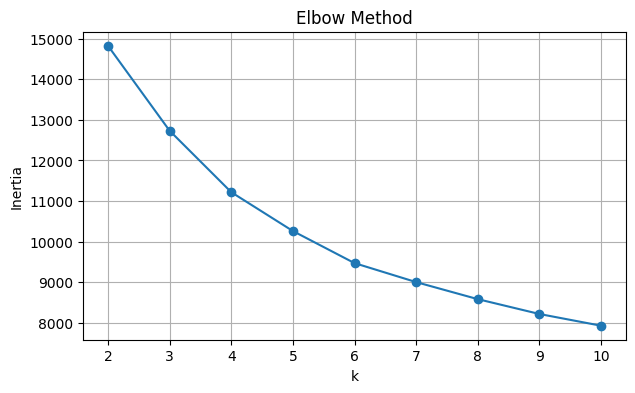

In [4]:
K = range(2,11)
inertia=[]
for k in K:
    inertia.append(KMeans(n_clusters=k,init='k-means++',n_init=10,random_state=42).fit(X).inertia_)
plt.figure(figsize=(7,4)); plt.plot(list(K),inertia,'o-')
plt.xlabel('k'); plt.ylabel('Inertia'); plt.title('Elbow Method'); plt.grid(True); plt.show()

## 5. Choose k - Silhouette score

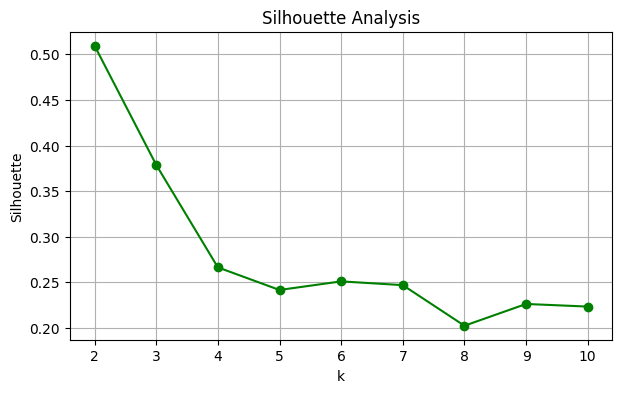

k=2: silhouette=0.509
k=3: silhouette=0.379
k=4: silhouette=0.266
k=5: silhouette=0.242
k=6: silhouette=0.251
k=7: silhouette=0.247
k=8: silhouette=0.202
k=9: silhouette=0.226
k=10: silhouette=0.223


In [5]:
sil=[]
for k in K:
    lab=KMeans(n_clusters=k,init='k-means++',n_init=10,random_state=42).fit_predict(X)
    sil.append(silhouette_score(X,lab))
plt.figure(figsize=(7,4)); plt.plot(list(K),sil,'o-',color='green')
plt.xlabel('k'); plt.ylabel('Silhouette'); plt.title('Silhouette Analysis'); plt.grid(True); plt.show()
for k,s in zip(K,sil): print(f'k={k}: silhouette={s:.3f}')

## 6. Fit the final model

Silhouette peaks at **k=2** (~0.51) - the cleanest split is 'high-value vs bargain-hunter'. We use **k=4** for interpretability (it separates the four channels) and state that trade-off openly.

In [6]:
k=4
df['Cluster']=KMeans(n_clusters=k,init='k-means++',n_init=10,random_state=42).fit_predict(X)
df['Cluster'].value_counts().sort_index()

Cluster
0    1222
1    1135
2    2069
3     574
Name: count, dtype: int64

## 7. Profile the clusters

In [7]:
profile=df.groupby('Cluster')[numeric_cols].mean().round(1)
profile['Customers']=df['Cluster'].value_counts().sort_index()
print(profile)
print('\nAcquisition Source mix per cluster (%):')
print((pd.crosstab(df['Cluster'],df['Acquisition_Source'],normalize='index')*100).round(0))

          Age    Income  Engagement_Time_Minutes  Purchase_Frequency  \
Cluster                                                                
0        29.9   55931.7                      3.5                 1.1   
1        45.0  103324.2                     14.7                 3.7   
2        30.3   54700.3                      3.4                 1.1   
3        41.4   85831.0                      8.8                 2.1   

         Average_Order_Value  Customers  
Cluster                                  
0                      368.4       1222  
1                     1939.0       1135  
2                      361.4       2069  
3                      823.2        574  

Acquisition Source mix per cluster (%):
Acquisition_Source  Facebook Ad  Groupon  Organic Search  Referral
Cluster                                                           
0                           0.0     99.0             0.0       1.0
1                           0.0      0.0           100.0       0.0
2     

> **What the profile shows.** Each cluster is ~99-100% a single acquisition channel - the segmentation essentially *recovers the four channels*. Useful for action, but it means K-Means adds little here beyond a channel groupby (noted honestly in README Limitations).

## 8. Name the clusters and export for Power BI

In [8]:
src=pd.crosstab(df['Cluster'],df['Acquisition_Source'],normalize='index')
label={'Organic Search':'Glow Ke Nawab (Organic VIPs)','Referral':'Hamesha 25 Club (Referral Regulars)','Groupon':'Gayab Grahak (Groupon One-Timers)','Facebook Ad':'Self-Care Sena (Facebook One-Timers)'}
names={c:label[src.loc[c].idxmax()] for c in src.index}
df['Cluster_Name']=df['Cluster'].map(names)
df.to_excel('medspa_clustered_v2.xlsx',index=False)
print('Saved medspa_clustered_v2.xlsx')
df[['Client_ID','Acquisition_Source','Cluster','Cluster_Name']].head()

Saved medspa_clustered_v2.xlsx


,Client_ID,Acquisition_Source,Cluster,Cluster_Name
0,EA-01502,Referral,2,Self-Care Sena (Facebook One-Timers)
1,EA-02587,Facebook Ad,2,Self-Care Sena (Facebook One-Timers)
2,EA-02654,Organic Search,1,Glow Ke Nawab (Organic VIPs)
3,EA-01056,Organic Search,1,Glow Ke Nawab (Organic VIPs)
4,EA-00706,Groupon,0,Gayab Grahak (Groupon One-Timers)
